In [134]:
import pandas as pd



## Import ISC

In [135]:
# PATH = '/media/rsafran/CORSAIR/isc-gem/'
PATH = '/media/rsafran/CORSAIR/isc-ehb/'
NAME_ISC = 'isc-ehb.csv'
# NAME_ISC = 'isc-gem-cat.csv'
# NAME_ISC = 'USGS_cat.csv' #in ehb file
isc_cnames = ['date','lat','lon','smajax','sminax','strike','q','depth','unc','q.1','mw','unc','q.2','s','mo','fac','mo_auth','mpp','mpr','mrr','mrt','mtp','mtt','str1','dip1','rake1','str2','dip2','rake2','type','eventid']

isc_cat_csv = pd.read_csv(PATH + NAME_ISC, comment='#',header=0,skipinitialspace=True)
# isc_cat_csv['date'] = pd.to_datetime(isc_cat_csv['date'],format='ISO8601', utc=True)
# isc_cat_csv['date'] = pd.to_datetime(isc_cat_csv['time'],format='ISO8601', utc=True) #USGS
isc_cat_csv.loc[:,'date'] = pd.to_datetime(isc_cat_csv.loc[:,'DATE'] + ' ' + isc_cat_csv.loc[:,'TIME'], format='ISO8601', utc=True)

In [136]:
isc_cat_csv

,EVENTID,TYPE,AUTHOR,DATE,TIME,LAT,LON,DEPTH,DEPFIX,DEPQUAL,AUTHOR.1,TYPE.1,MAG,MAG_AU,MAG_TYPE,MW,n,date
0,619609337,se,ISC-EHB,2017-12-01,00:06:13.49,-6.336,130.116,146.3,NaN,L2,ISC,mb,4.9,NaN,NaN,NaN,NaN,2017-12-01 00:06:13.490000+00:00
1,619609338,se,ISC-EHB,2017-12-01,01:18:58.06,-17.908,-178.504,565.7,NaN,L2,ISC,mb,4.7,NaN,NaN,NaN,NaN,2017-12-01 01:18:58.060000+00:00
2,619609339,se,ISC-EHB,2017-12-01,02:30:00.07,-48.778,106.864,10.0,TRUE,L3,ISC,mb,4.9,ISC,MS,5.1,NaN,2017-12-01 02:30:00.070000+00:00
3,619609340,ke,ISC-EHB,2017-12-01,02:32:45.70,30.707,57.339,13.6,NaN,L1,ISC,mb,6.0,ISC,MS,6.0,NaN,2017-12-01 02:32:45.700000+00:00
4,619609341,se,ISC-EHB,2017-12-01,02:43:27.20,30.684,57.393,15.7,NaN,L1,ISC,mb,5.1,NaN,NaN,NaN,NaN,2017-12-01 02:43:27.200000+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10297,624625611,se,ISC-EHB,2019-03-31,23:42:33.27,7.713,94.281,30.0,TRUE,L3,ISC,mb,4.7,NaN,NaN,NaN,NaN,2019-03-31 23:42:33.270000+00:00
10298,624625612,se,ISC-EHB,2019-03-31,23:44:44.26,7.663,94.104,20.8,NaN,L1,ISC,mb,4.9,ISC,MS,4.8,NaN,2019-03-31 23:44:44.260000+00:00
10299,624625613,se,ISC-EHB,2019-03-31,23:46:41.84,7.666,94.050,21.3,NaN,L1,ISC,mb,5.1,ISC,MS,4.8,NaN,2019-03-31 23:46:41.840000+00:00
10300,624625614,se,ISC-EHB,2019-03-31,23:48:57.49,7.526,94.138,20.0,TRUE,L3,ISC,mb,4.6,NaN,NaN,NaN,NaN,2019-03-31 23:48:57.490000+00:00


In [137]:
isc_cat_csv.dropna(axis=1, how='any', inplace=True)
isc_cat_csv.rename(columns= {'LAT':'lat', 'LON':'lon','latitude':'lat', 'longitude':'lon', "DEPTH": "depth","MAG":'mw',"mag":'mw', 'EVENTID':'eventid', 'id':'eventid'}, inplace=True)
isc_cat_csv.sort_values('date', inplace=True)


In [138]:
isc_cat_csv = isc_cat_csv[(isc_cat_csv['date'] > '2018-01-01') & (isc_cat_csv['date'] < '2019-02-01' )]

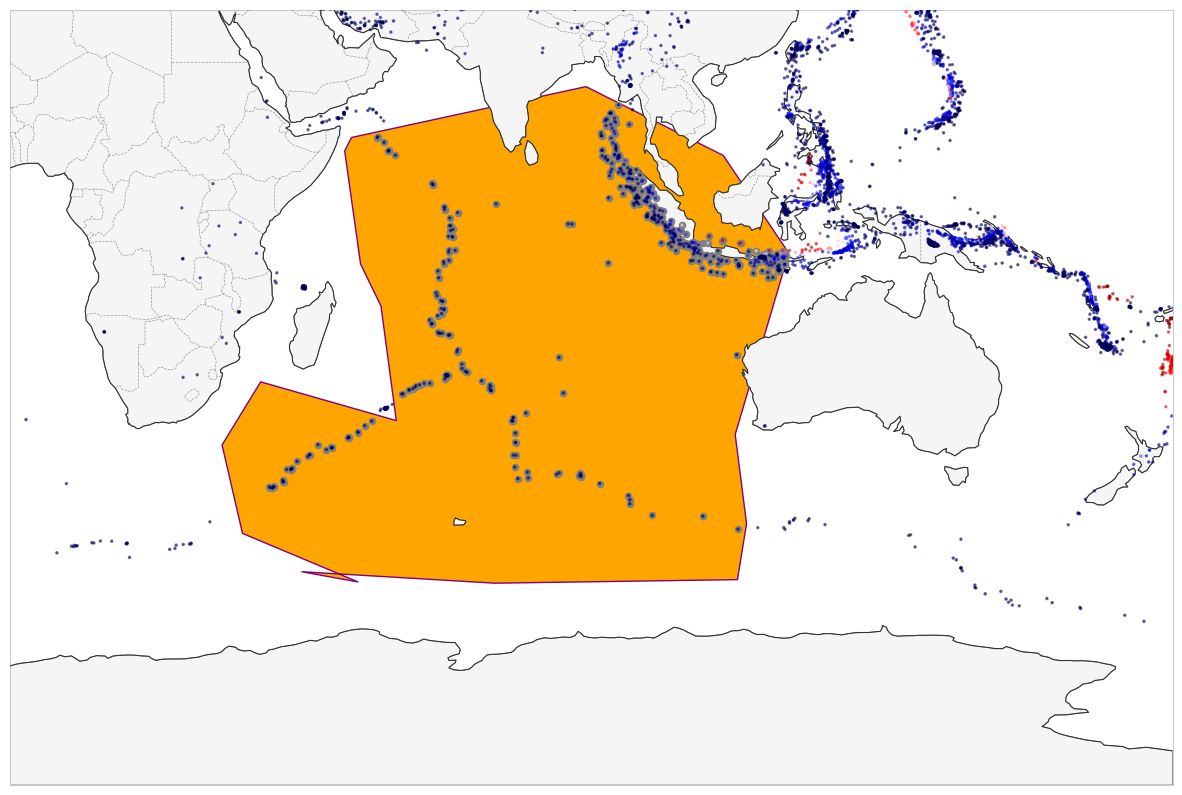

In [139]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.path as mpltPath
import pandas as pd
from matplotlib.colors import LightSource
import xarray as xr
import os

# ---------------------------------------------------------
# Projection centrée
# ---------------------------------------------------------
# ortho = ccrs.Orthographic(central_longitude=central_lon, central_latitude=central_lat)
pc = ccrs.PlateCarree()
fig, axis = plt.subplots(figsize=(15, 15), subplot_kw=dict(projection=pc))

# ---------------------------------------------------------
# Terres et côtes (couleurs claires pour impression)
# ---------------------------------------------------------
axis.add_feature(cfeature.LAND, facecolor="#f5f5f5", edgecolor="#666666", linewidth=0.5, zorder=2)
axis.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="#333333", zorder=3)
axis.add_feature(cfeature.BORDERS, linestyle="--", linewidth=0.5, edgecolor="#999999", zorder=3)
axis.set_xlim(-0, 180)
axis.set_ylim(-90, 30)
axis.scatter(
    isc_cat_csv["lon"],
    isc_cat_csv["lat"],
    s=isc_cat_csv["mw"]*2,
    c=isc_cat_csv["depth"],
    marker=".",
    cmap='seismic',
    transform=pc,
    alpha=0.5,
    zorder=4,
)

y = np.array([  [12.280,88.756],
         [-2.742,92.799],
         [-12.829,108.795],
         [-15.047,116.881],
         [-8.859,125.670],
         [6.210,103.698],
         [11.936,91.042],
          ])

y_indian = np.array([[10.260,52.875],
                    # [24.316,67.640],
                    [18.133,89.187],
                    [7.482,110.437],
                    [-7.636,120.578],
                    [-35.729,112.289],
                    [-49.533,114.047],
                    [-58.200,112.640],
                    [-58.751,75.023],
                    [-56.974,45.140],
                    [-58.569,53.929],
                    [-51.043,36.000],
                    [-37.345,32.836],
                    [-27.577,38.812],
                    [-33.577,59.812],
                    # [-28.199,45.468],
                    [-15.846,57.445],
                    [-9.331,54.281],
                    [8.178,51.820],
                    ])

p = Polygon(y_indian[:,::-1], facecolor="orange", edgecolor="purple")

isc_formatted = np.hstack((isc_cat_csv[['lon']].values.flatten()[:,np.newaxis],isc_cat_csv[['lat']].values.flatten()[:,np.newaxis]))
path = mpltPath.Path(y_indian[:,::-1])
inside2 = path.contains_points(isc_formatted)
isc_cat_csv[inside2].plot(x='lon', y='lat', ax=axis, kind='scatter', color='gray', marker='o',  zorder=3)
axis.add_patch(p)
plt.show()

In [140]:
sumatra_isc = isc_cat_csv[inside2]
print(len(sumatra_isc))

571


## Load detections

In [335]:
from utils.data_reading.sound_data.station import StationsCatalog
import pickle
import datetime
import glob2
from pathlib import Path

from utils.physics.sound_model.ellipsoidal_sound_model import GridEllipsoidalSoundModel
from utils.detection.association_geodesic_ridges import compute_candidates, update_valid_grid, update_results, load_detections, compute_grids

import os
from utils.physics.sound_model.ellipsoidal_sound_model import GridEllipsoidalSoundModel

# paths
CATALOG_PATH = "/media/rsafran/CORSAIR/OHASISBIO/recensement_stations_OHASISBIO_RS.csv"  # csv catalog files
DETECTIONS_DIR = "/media/rsafran/CORSAIR/T-pick_2.2"  # where we have detection pickles
ISAS_PATH = "/media/rsafran/CORSAIR/ISAS/extracted/2018"
YEAR = 2018
 # output dir
ASSOCIATIONS_DIR = f"../../data/detection/T-pick_2.2/{YEAR}"
Path(ASSOCIATIONS_DIR).mkdir(exist_ok=True)

# delimitation of the detections we keep (this notebook actually associates the detections of 1 year and 4 hours)
DATE_START = datetime.datetime(YEAR, 1, 1) - datetime.timedelta(hours=2)
DATE_END = datetime.datetime(YEAR+1, 3, 1) + datetime.timedelta(hours=2)

# Detections loading parameters
MIN_P_TISSNET_PRIMARY = 0.5 # min probability of browsed detections
MIN_P_TISSNET_SECONDARY = 0.45 # min probability of detections that can be associated with the browsed one
MERGE_DELTA_S = 10 # threshold below which we consider two events should be merged

# The REQ_CLOSEST_STATIONS th closest stations will be required for an association to be valid
# e.g. if we set it to 6, no association of size <6 will be saved (this is useful to save memory)
REQ_CLOSEST_STATIONS = 6

# sound model definition

arr = os.listdir(ISAS_PATH)
file_list = [os.path.join(ISAS_PATH, fname) for fname in arr if fname.endswith('.nc')]
SOUND_MODEL = GridEllipsoidalSoundModel(file_list)

# association running parameters
SAVE_PATH_ROOT = None  # change this to save the grids as figures, leave at None by default

STATIONS = StationsCatalog(CATALOG_PATH).filter_out_undated().filter_out_unlocated()
# load detection files and keep all the ones that are included in the wanted year
FILES = {}
for f in glob2.glob(f"{DETECTIONS_DIR}/*.pkl"):
    det_files = [f for f in glob2.glob(DETECTIONS_DIR + "/*") if Path(f).is_file()]
    det_files = [f for f in det_files if "2018" in f ]
    dataset, s_name = f[:-4].split("/")[-1].split("_")
    s = STATIONS.by_dataset(dataset).by_name(s_name)
    if len(s) != 1:
        print(f"station {dataset}_{s_name} not found or not unique")
        continue
    FILES[s[0]] = f
FILES = {s : FILES[s] for s in FILES if (s.date_end > DATE_START and s.date_start < DATE_END)}


FILES_2018 = {}
for key in FILES.keys() :
    if key.dataset == "OHASISBIO-2018" or key.dataset == "IMS-2018":
        FILES_2018[key] = FILES[key]
FILES = FILES_2018

station IMS-2014_H01W1 not found or not unique
station IMS-2013_H08S1 not found or not unique
station IMS-2006_H01W1 not found or not unique
station IMS-2006_H08N1 not found or not unique
station IMS-2006_H08S1 not found or not unique
station IMS-2012_H01W1 not found or not unique
station IMS-2012_H08N1 not found or not unique
station IMS-2012_H08S1 not found or not unique
station IMS-2007_H08N1 not found or not unique
station IMS-2007_H08S1 not found or not unique
station IMS-2008_H01W1 not found or not unique
station IMS-2010_H01W1 not found or not unique
station IMS-2010_H08S1 not found or not unique
station IMS-2008_H08S1 not found or not unique
station IMS-2013_H01W1 not found or not unique
station IMS-2011_H08N1 not found or not unique
station IMS-2011_H08S1 not found or not unique
station IMS-2008_H08N1 not found or not unique
station IMS-2015_H01W1 not found or not unique
station IMS-2015_H08S1 not found or not unique
station IMS-2016_H01W1 not found or not unique
station IMS-2

In [336]:
start_times = {}
for s in STATIONS :
    start_times[s.name] = s.date_start

start_times

{'MAD': datetime.datetime(2016, 1, 29, 9, 26, 44),
 'NCRO1': datetime.datetime(2011, 1, 20, 4, 13, 55),
 'NCRO2': datetime.datetime(2011, 1, 21, 0, 40, 34),
 'NCRO3': datetime.datetime(2016, 1, 8, 14, 42, 27),
 'NEAMS': datetime.datetime(2020, 1, 26, 11, 5, 38),
 'SWAMS': datetime.datetime(2022, 2, 25, 5, 46, 40),
 'WKER2': datetime.datetime(2022, 2, 17, 9, 25, 6),
 'WKER3': datetime.datetime(2013, 2, 16, 18, 53, 21),
 'WKER1': datetime.datetime(2013, 2, 15, 17, 6, 10),
 'RAMA': datetime.datetime(2012, 5, 4, 13, 30, 57),
 'SSEIR': datetime.datetime(2022, 2, 28, 14, 5, 22),
 'SWAMS1': datetime.datetime(2016, 1, 21, 1, 46, 46),
 'SWAMS2': datetime.datetime(2014, 2, 7, 22, 35, 48),
 'SWAMS3': datetime.datetime(2015, 1, 27, 16, 41, 11),
 'SWAMS2-Bbot': datetime.datetime(2015, 1, 27, 5, 34, 12),
 'SWAMS2-Atop': datetime.datetime(2015, 1, 27, 5, 22, 50),
 'NSPA': datetime.datetime(2016, 1, 23, 9, 53, 22),
 'SWAMS3-bot': datetime.datetime(2016, 1, 21, 15, 6, 59),
 'MADE': datetime.datetime(20

In [337]:
drift_ppm =  {'WKER2'    : np.float64(0.07070609464587818) ,
              'SSEIR'    : np.float64(0.056829561501103854),
              'SWAMS-bot': np.float64(0.06392609752658984),
              'SSWIR'    : np.float64(0.02821098177285819),
              'H01W1'    : np.float64(0.044812489274903555),
              'H04N1'    : np.float64(0.059873871194326966),
              'H08S1'    : np.float64(0.09184142057971911),
              'MADW'     : np.float64(0.15179620993510667),
              'RTJ'      : np.float64(0.03300404727291095),
              'NEAMS'    : np.float64(0.19651681582022462),
              'MADE'     : np.float64(0.20989200377741213),
              'ELAN'     : np.float64(-0.2120614076561722)}

drift_ppm =  {'WKER2': np.float64(0.018819465985586703)*0,
             'SSEIR': np.float64(-0.00944394917823388)*0,
             'SWAMS-bot': np.float64(0.013707895485381982)*0,
             'SSWIR': np.float64(-0.019508789139699445)*0,
             'H01W1': np.float64(-0.03680328319877191)*0,
             'H04N1': np.float64(0.03136013138060889)*0,
             'H08S1': np.float64(0.016367138533368575)*0,
             'MADW': np.float64(0.12329683807266179)*0,
             'RTJ': np.float64(-0.0915411273449962)*0,
             'NEAMS': np.float64(0.1582222404206135)*0,
             'MADE': np.float64(0.10428635977000056)*0,
             'ELAN': np.float64(-0.20246759324660246)*0}


# drift_ppm =  {'WKER2':    np.float64(0),
#              'SSEIR':     np.float64(0.049),
#              'SWAMS-bot': np.float64(0.0048),
#              'SSWIR':     np.float64(0.0346),
#              'H01W1':     np.float64(0),
#              'H04N1':     np.float64(0),
#              'H08S1':     np.float64(0),
#              'MADW':      np.float64(0.147),
#              'RTJ':       np.float64(-0.056),
#              'NEAMS':     np.float64(0.116),
#              'MADE':      np.float64(-0.097),
#              'ELAN':      np.float64(-0.022)}




# drift_ppm = {'WKER2': np.float64(0.015675690745453608),
#  'SSEIR': np.float64(-0.017848637345885265),
#  'SWAMS-bot': np.float64(-0.0001326337928375665),
#  'SSWIR': np.float64(-0.009818433177599672),
#  'H01W1': np.float64(-0.029798680967196844),
#  'H04N1': np.float64(0.020578497128553863),
#  'H08S1': np.float64(0.017011216213447256),
#  'MADW': np.float64(0.13361935513600542),
#  'RTJ': np.float64(-0.09547205492843602),
#  'NEAMS': np.float64(0.16846456629693307),
#  'MADE': np.float64(0.12115202263629499),
#  'ELAN': np.float64(-0.13154459233000182)}


drift_ppm_val= {'SSEIR' : -0.02250,
'RTJ  ' : -0.04949,
'NEAMS' :  0.00253,
'MADW ' :  0.35267,
'SSWIR' :  0.43526,
'MADE ' :  0.24550,
'WKER2' :  0.07503,
'ELAN ' : -0.22977,
'SWAMS-bot' :  0.000000}


for k in drift_ppm.keys():
    if k in drift_ppm_val.keys() :
        drift_ppm[k] = drift_ppm[k]+drift_ppm_val[k]
    else :
        drift_ppm[k] = 0.


# load properly the detection files
Path(f"{ASSOCIATIONS_DIR}/cache").mkdir(parents=True, exist_ok=True)
DET_PATH = f"{ASSOCIATIONS_DIR}/cache/detections_{MIN_P_TISSNET_SECONDARY}_{MERGE_DELTA_S}.pkl"
if True : #not Path(DET_PATH).exists():
    DETECTIONS = load_detections(list(FILES.values()), STATIONS, MIN_P_TISSNET_SECONDARY, merge_delta=datetime.timedelta(seconds=MERGE_DELTA_S))

    for s in DETECTIONS.keys():
        DETECTIONS[s] = DETECTIONS[s][(DETECTIONS[s][:,0] > DATE_START) & (DETECTIONS[s][:,0] < DATE_END)]

        if 'H04N1' in s.name :
            drift_errors = np.array(list(map(lambda i : datetime.timedelta(seconds=6.8) + datetime.timedelta(seconds=s.get_clock_error(i,drift_ppm=drift_ppm[s.name])),DETECTIONS[s][:,0]))).T
            DETECTIONS[s][:,0] = DETECTIONS[s][:,0] - drift_errors
        if 'ELAN' in s.name :
            drift_errors = np.array(list(map(lambda i : datetime.timedelta(seconds=-2.6) + datetime.timedelta(seconds=s.get_clock_error(i,drift_ppm=drift_ppm[s.name])),DETECTIONS[s][:,0]))).T
            DETECTIONS[s][:,0] = DETECTIONS[s][:,0] - drift_errors

        elif s.name in drift_ppm.keys() :
            drift_errors = np.array(list( map( lambda i : datetime.timedelta(seconds=s.get_clock_error(i,drift_ppm=drift_ppm[s.name])),  DETECTIONS[s][:,0]   ))).T
            DETECTIONS[s][:,0] = DETECTIONS[s][:,0] - drift_errors

    # with open(DET_PATH, "wb") as f:
    #     pickle.dump(DETECTIONS, f)
else:
    with open(DET_PATH, "rb") as f:
        DETECTIONS = pickle.load(f)

# do not keep detection entries for which the detection list is empty
to_del = []
for s in DETECTIONS.keys():
    if len(DETECTIONS[s]) == 0:
        to_del.append(s)
    if s.name == 'H04S1':# or s.name == 'H04N1' or s.name == 'H01W1':
        to_del.append(s)
for s in to_del:
    del DETECTIONS[s]

# assign an index to each detection
idx_det = 0
IDX_TO_DET = {}
for idx, s in enumerate(DETECTIONS.keys()):
    s.idx = idx  # indexes to store efficiently the associations
    DETECTIONS[s] = list(DETECTIONS[s])
    for i in range(len(DETECTIONS[s])):
        DETECTIONS[s][i] = np.concatenate((DETECTIONS[s][i], [idx_det]))
        IDX_TO_DET[idx_det] = DETECTIONS[s][i]
        idx_det += 1
    DETECTIONS[s] = np.array(DETECTIONS[s])
DETECTION_IDXS = np.array(list(range(idx_det)))

# only keep the stations that appear in the kept detections
STATIONS = [s for s in DETECTIONS.keys()]
FIRSTS_DETECTIONS = {s : DETECTIONS[s][0,0] for s in STATIONS}
LASTS_DETECTIONS = {s : DETECTIONS[s][-1,0] for s in STATIONS}


Found 5310 detections for station OHASISBIO-2018_WKER2
Found 19098 detections for station OHASISBIO-2018_SSEIR
Found 9040 detections for station OHASISBIO-2018_SWAMS-bot
Found 10537 detections for station OHASISBIO-2018_SSWIR
Found 12670 detections for station IMS-2018_H01W1
Found 27777 detections for station IMS-2018_H04N1
Found 7848 detections for station IMS-2018_H04S1
Found 15882 detections for station IMS-2018_H08S1
Found 14477 detections for station OHASISBIO-2018_MADW
Found 22761 detections for station OHASISBIO-2018_RTJ
Found 18873 detections for station OHASISBIO-2018_NEAMS
Found 8215 detections for station OHASISBIO-2018_MADE
Found 7113 detections for station OHASISBIO-2018_ELAN


In [338]:
s_coords = {}
s_obj = {}
for s in STATIONS :
    s_coords[s.name]=s.get_pos()
    s_obj[s.name] = s

In [339]:
# i = 67474
# travel_time = SOUND_MODEL.get_sound_travel_time(s_coords[name], sumatra_isc[['lat','lon']].loc[i].values,sumatra_isc[['date']].loc[i].dt.to_pydatetime()[0])
# datetime.timedelta(seconds=travel_time)
# print(sumatra_isc[['date']].loc[i])
# sumatra_isc[['date']].loc[i]+datetime.timedelta(seconds=travel_time)
# sumatra_isc

## compute arrivals

In [340]:
sumatra_final = sumatra_isc.copy()
names = {1: 'ELAN', 2:'WKER2', 3: 'H04N1', 4: 'SSWIR', 5: 'SWAMS-bot', 6:'MADW'}

names =  {1:'WKER2',
         2:'SSEIR',
         3 :'SWAMS-bot',
         4 :'SSWIR',
         5 :'H01W1',
         6 :'H04N1',
         7 :'H08S1',
         8 :'MADW',
         9 :'RTJ',
         10:'NEAMS',
         11:'MADE',
         12:'ELAN'}

for station_id, name in names.items():

    sumatra_final[f'travel_time_{name}'] = sumatra_final.apply(
        lambda row: SOUND_MODEL.get_sound_travel_time(
            s_coords[name],
            row[['lat', 'lon']].values,
            row['date']
        ),
        axis=1
    )

    sumatra_final[f'expected_arrival_{name}'] = (
        sumatra_final['date']
        + pd.to_timedelta(sumatra_final[f'travel_time_{name}'], unit='s')
    )

    # --- détections station ---
    df_det = pd.DataFrame(
        DETECTIONS[s_obj[name]],
        columns=['detection', 'probability', 'idx']
    )

    df_det['detection'] = pd.to_datetime(df_det['detection'], utc=True)
    df_det = df_det.sort_values('detection')

    # --- merge asof ---
    tmp = sumatra_final[['eventid', f'expected_arrival_{name}']].copy()
    tmp = tmp.sort_values(f'expected_arrival_{name}')

    tmp = pd.merge_asof(
        tmp,
        df_det,
        left_on=f'expected_arrival_{name}',
        right_on='detection',
        tolerance=pd.Timedelta(seconds=120),
        direction='nearest'
    )

    # --- rattachement au dataframe principal ---
    sumatra_final = sumatra_final.merge(
        tmp[['eventid', 'detection']],
        on='eventid',
        how='left'
    )

    sumatra_final.rename(
        columns={'detection': f'detection_{name}'},
        inplace=True
    )

    # --- erreur ---
    sumatra_final[f'diff_{name}'] = (
        sumatra_final[f'expected_arrival_{name}']
        - sumatra_final[f'detection_{name}']
    ).dt.total_seconds()

sumatra_isc

,eventid,TYPE,AUTHOR,DATE,TIME,lat,lon,depth,DEPQUAL,AUTHOR.1,TYPE.1,mw,date
588,621014221,se,ISC-EHB,2018-01-01,06:22:46.68,-6.244,101.980,15.0,L3,ISC,mb,4.4,2018-01-01 06:22:46.680000+00:00
589,621014222,se,ISC-EHB,2018-01-01,07:26:02.16,-4.265,102.179,59.3,L1,ISC,mb,4.8,2018-01-01 07:26:02.160000+00:00
593,621014226,se,ISC-EHB,2018-01-01,16:25:35.71,-7.779,116.809,297.0,L2,ISC,mb,4.0,2018-01-01 16:25:35.710000+00:00
601,621014234,se,ISC-EHB,2018-01-02,02:16:18.24,-38.854,46.408,10.3,L1,ISC,mb,5.0,2018-01-02 02:16:18.240000+00:00
615,621014248,se,ISC-EHB,2018-01-02,20:47:43.11,7.070,92.095,28.0,L1,ISC,mb,4.7,2018-01-02 20:47:43.110000+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8943,624624230,se,ISC-EHB,2019-01-23,11:39:02.26,-10.200,118.892,22.3,L1,ISC,mb,5.8,2019-01-23 11:39:02.260000+00:00
8944,624624231,se,ISC-EHB,2019-01-23,12:36:10.96,-10.324,119.033,16.6,L1,ISC,mb,5.0,2019-01-23 12:36:10.960000+00:00
9003,624624290,se,ISC-EHB,2019-01-26,16:36:10.94,1.918,97.875,55.2,L1,ISC,mb,4.8,2019-01-26 16:36:10.940000+00:00
9012,624624299,se,ISC-EHB,2019-01-27,04:37:02.66,1.550,94.932,20.0,L3,ISC,mb,4.5,2019-01-27 04:37:02.660000+00:00


<Axes: xlabel='date', ylabel='diff_ELAN'>

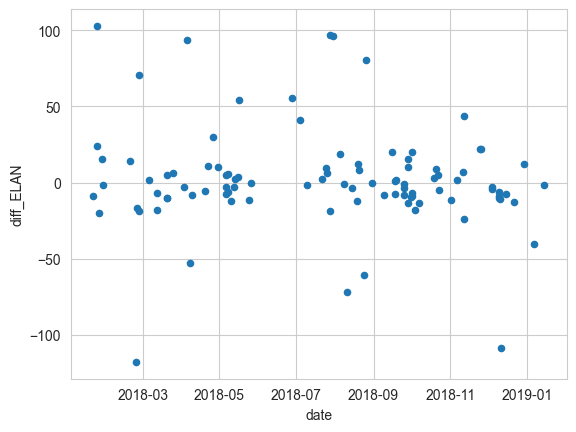

In [341]:
sumatra_final.plot(x='date',y='diff_ELAN', kind='scatter', legend=False, ax=plt.gca())
# plt.errorbar(x = sumatra_final.date, y = sumatra_final.diff_ELAN, yerr= sumatra_final.rms*10, fmt='+' )

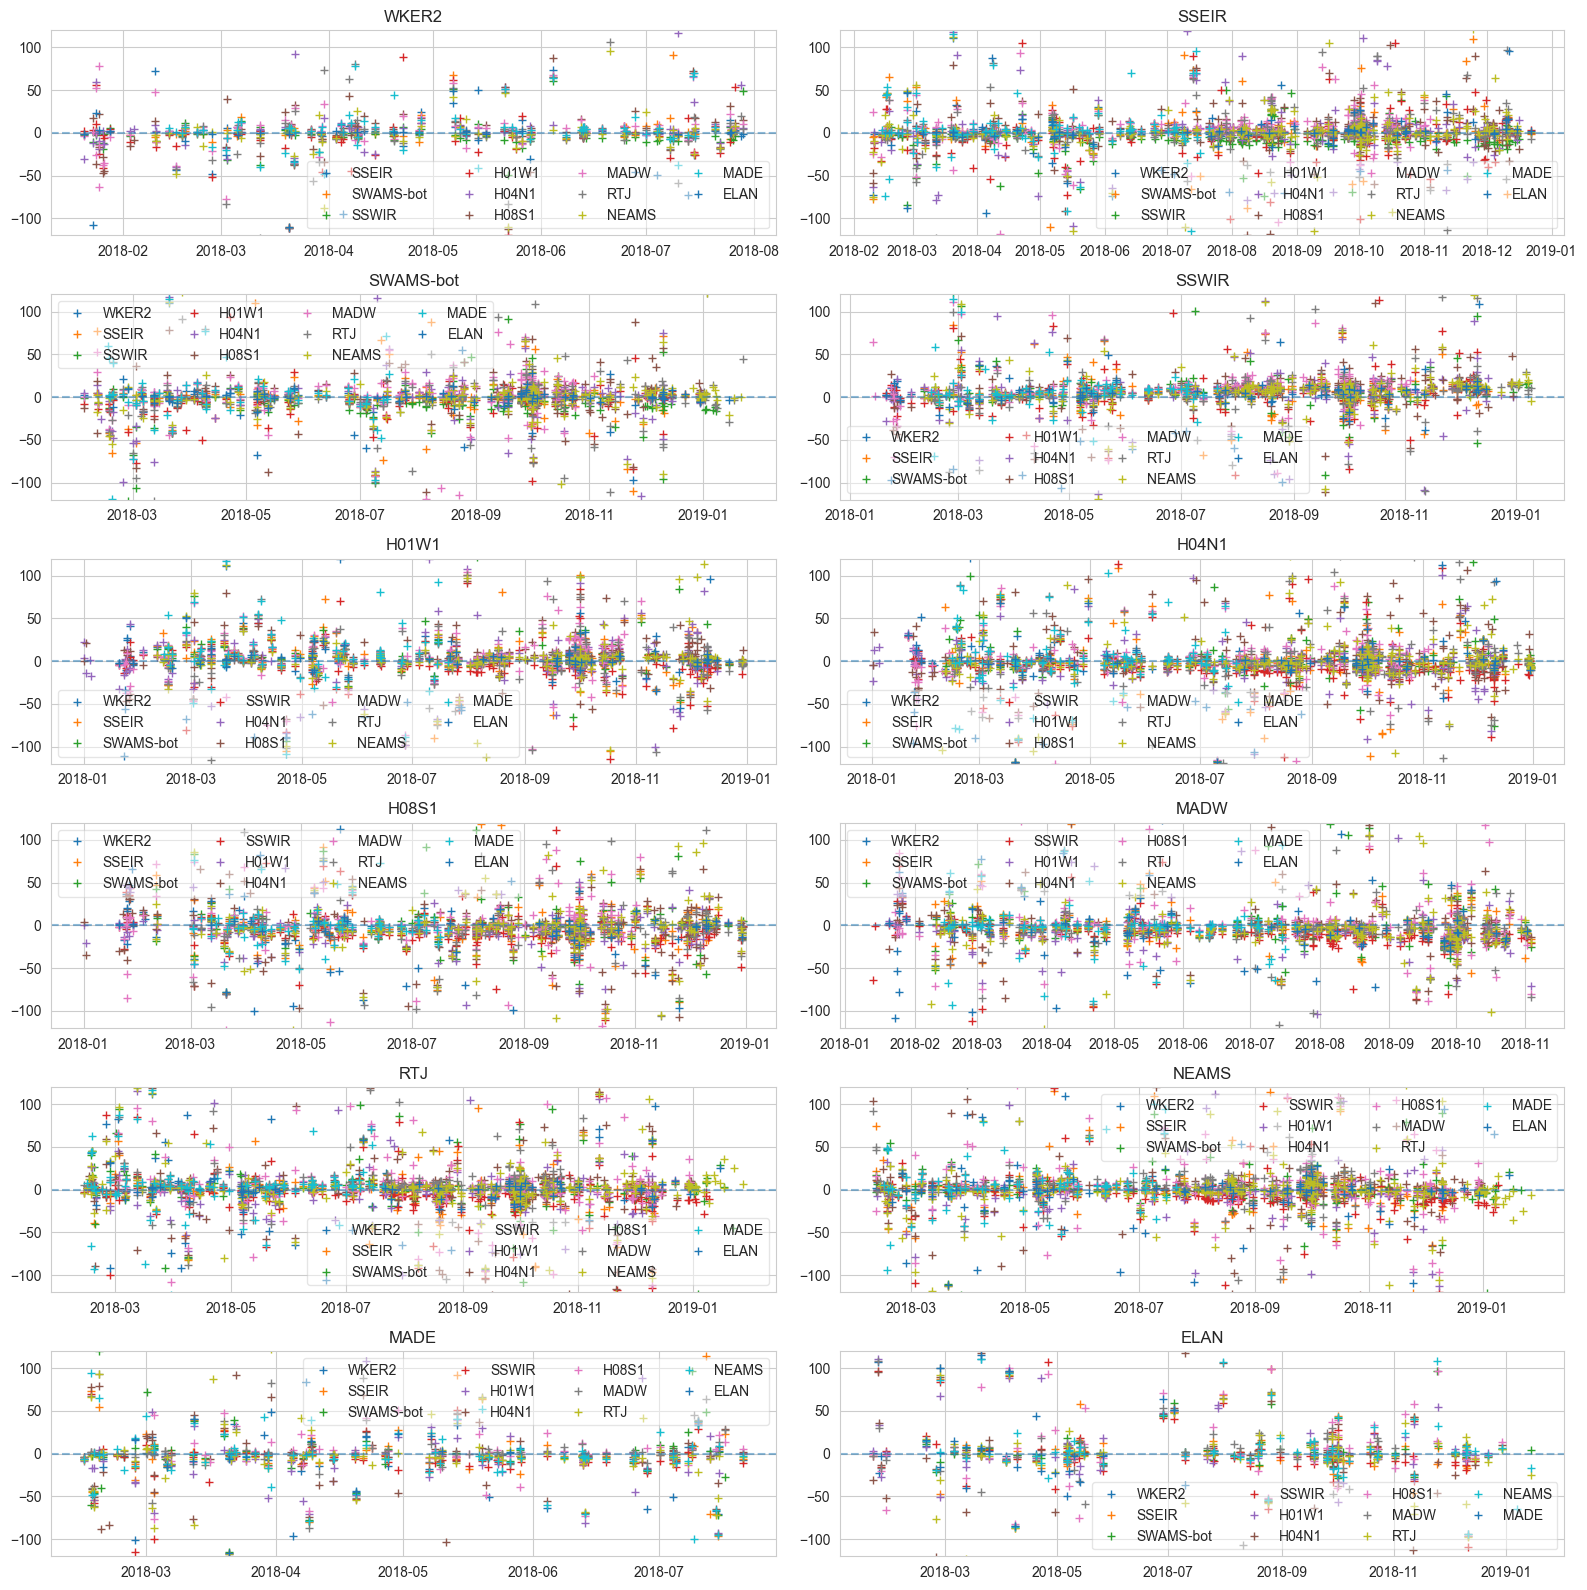

In [342]:
plt.figure(figsize=(16, 16))

stations = list(names.values())

for i, sta_ref in enumerate(stations):
    plt.subplot(6, 2, i + 1)
    plt.title(sta_ref)

    for sta_cmp in stations:
        if sta_cmp == sta_ref:
            continue

        mask = (
            sumatra_final[f'diff_{sta_ref}'].notna()
            & sumatra_final[f'diff_{sta_cmp}'].notna()
        )

        plt.plot(
            sumatra_final.loc[mask, 'date'],
            sumatra_final.loc[mask, f'diff_{sta_ref}']
            - sumatra_final.loc[mask, f'diff_{sta_cmp}'],
            '+',
            label=sta_cmp
        )

    plt.ylim(-120,120)
    plt.axhline(0, linestyle='--', alpha=0.5)
    plt.legend(framealpha=0.5, ncol=4)

plt.tight_layout()


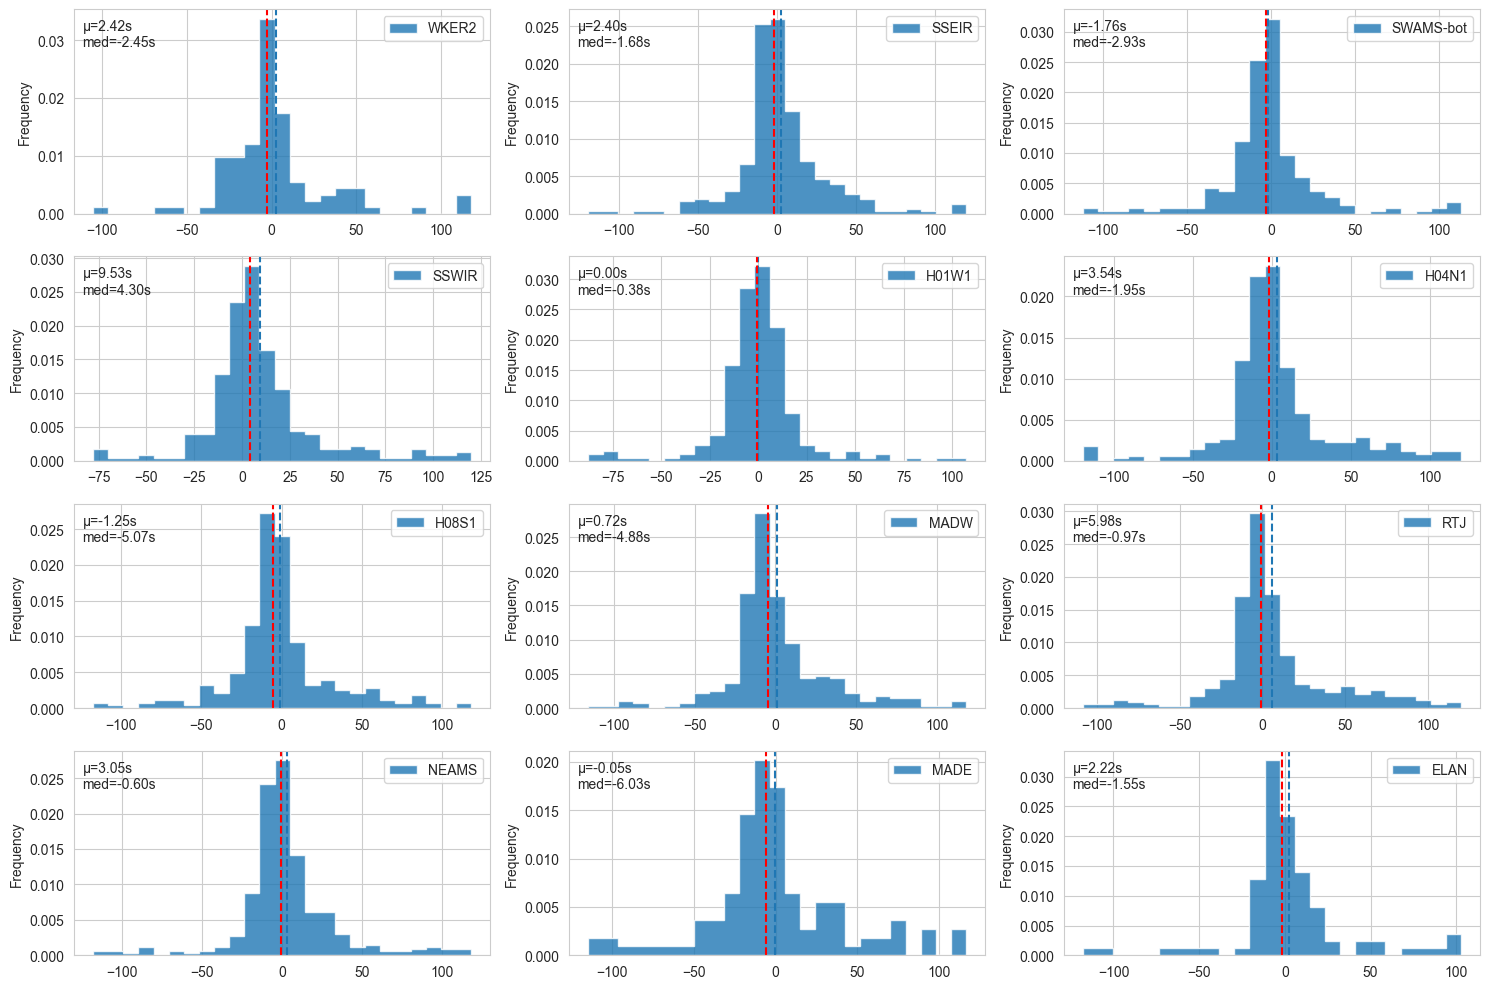

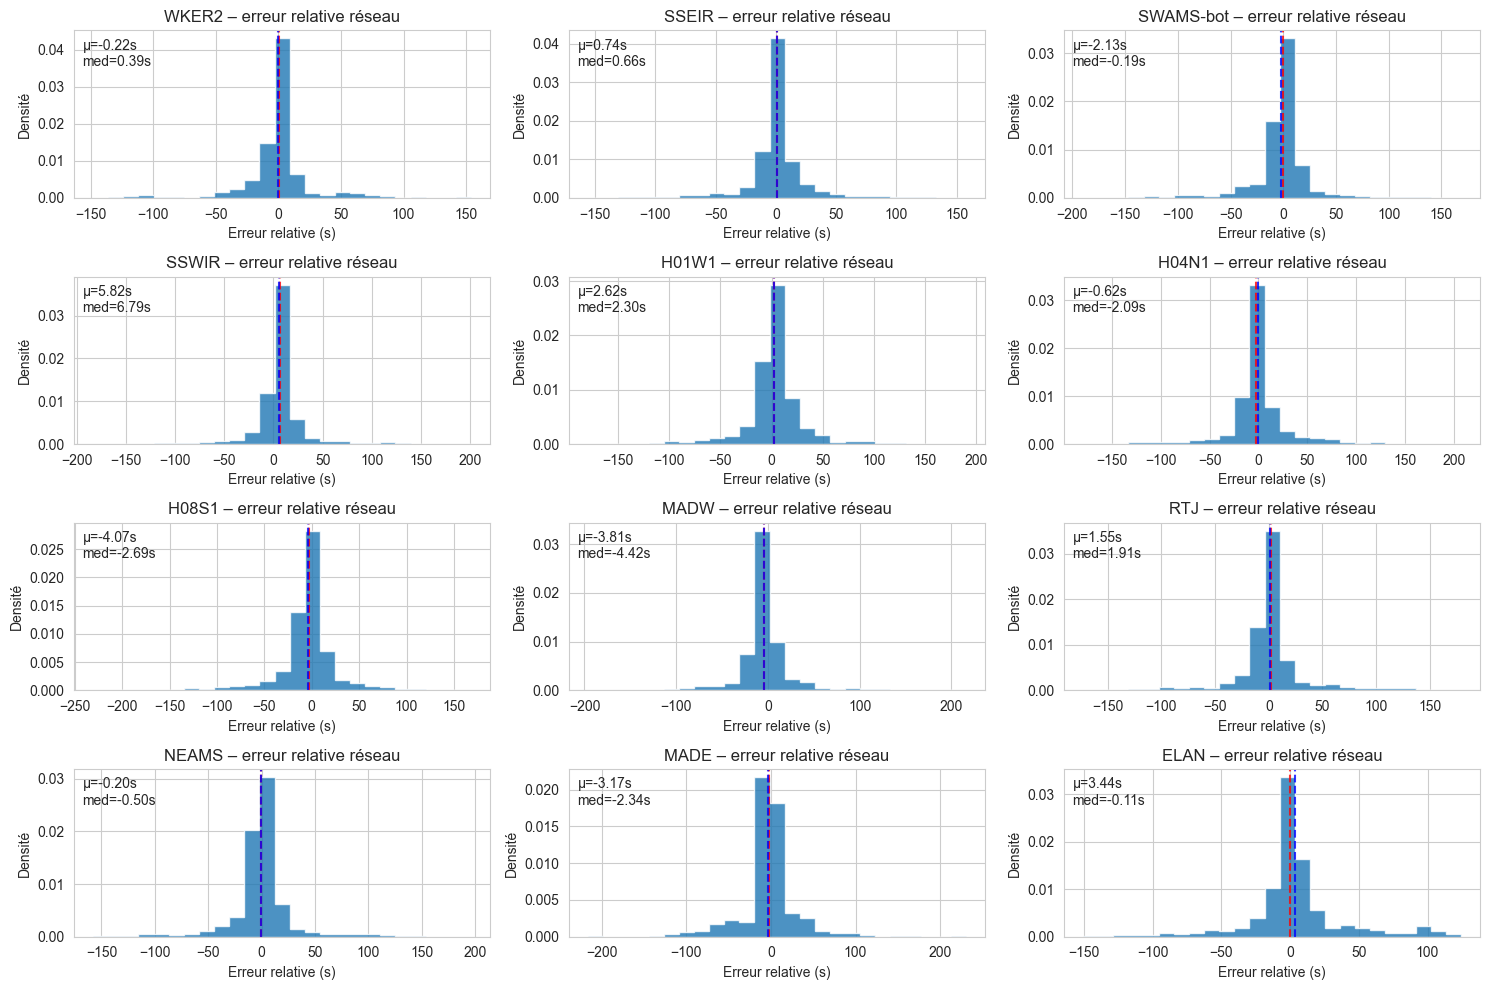

In [343]:
plt.figure(figsize=(15, 10))
for i, sta_ref in enumerate(stations):
    plt.subplot(4, 3, i + 1)
    sumatra_final[f'diff_{sta_ref}'].plot(kind='hist',bins = 25,density=True ,histtype='stepfilled',alpha=0.8, label=sta_ref)
    plt.axvline(np.nanmean(sumatra_final[f'diff_{sta_ref}'].values), linestyle='--', alpha=1)
    plt.axvline(np.nanmedian(sumatra_final[f'diff_{sta_ref}'].values), linestyle='--',color='r', alpha=1)
    plt.text(
    0.02, 0.95,
    f"μ={np.nanmean(sumatra_final[f'diff_{sta_ref}'].values):.2f}s\nmed={np.nanmedian(sumatra_final[f'diff_{sta_ref}'].values):.2f}s",
    transform=plt.gca().transAxes,
    va='top'
    )
    plt.legend()

plt.tight_layout()
plt.figure(figsize=(15,10))
stations = list(names.values())
bins = 25
for i, sta_ref in enumerate(stations):
    plt.subplot(4, 3, i + 1)
    plt.title(f"{sta_ref} – erreur relative réseau")

    all_errors = []

    for sta_cmp in stations:
        if sta_cmp == sta_ref:
            continue

        diff = (
            sumatra_final[f'diff_{sta_ref}']
            - sumatra_final[f'diff_{sta_cmp}']
        ).dropna()

        all_errors.append(diff.values)

    all_errors = np.concatenate(all_errors)

    plt.hist(
        all_errors,
        bins=bins,
        density=True,
        histtype='stepfilled',
        alpha=0.8
    )

    plt.axvline(np.nanmedian(all_errors), linestyle='--',color="r", alpha=0.8, label='median')
    plt.axvline(np.nanmean(all_errors), linestyle='--',color="b", alpha=0.8, label='mean')
    plt.text(
        0.02, 0.95,
        f"μ={np.nanmean(all_errors):.2f}s\nmed={np.nanmedian(all_errors):.2f}s",
        transform=plt.gca().transAxes,
        va='top'
    )

    plt.xlabel("Erreur relative (s)")
    plt.ylabel("Densité")

plt.tight_layout()



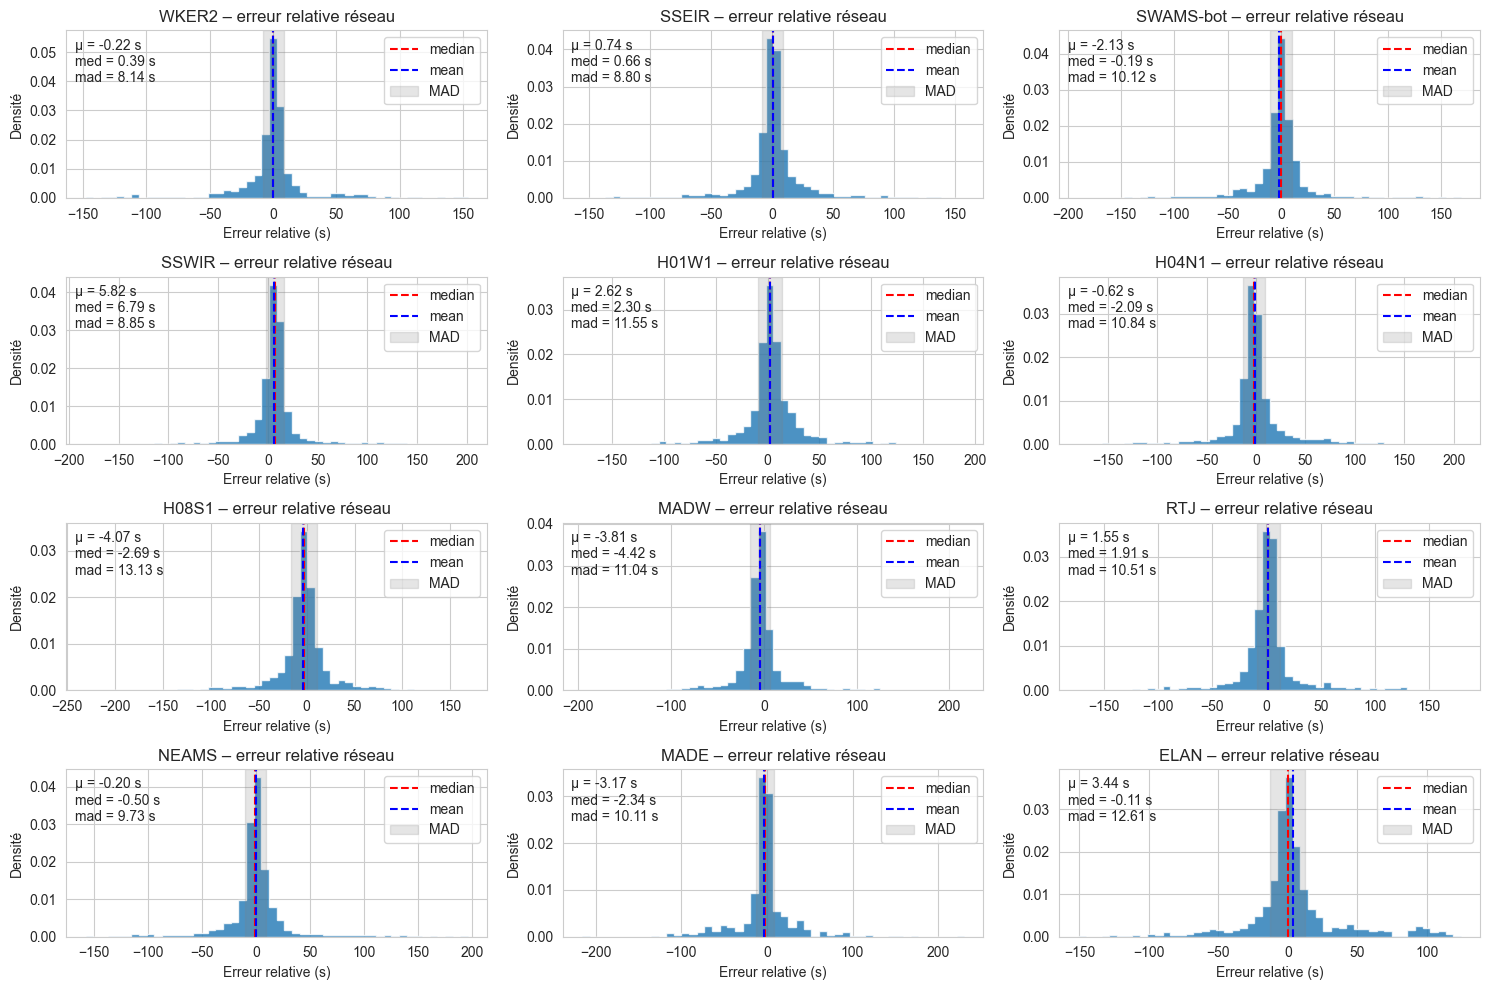

In [344]:
from scipy.stats import median_abs_deviation
plt.figure(figsize=(15, 10))
bins = 50

for i, sta_ref in enumerate(stations):
    plt.subplot(4, 3, i + 1)
    plt.title(f"{sta_ref} – erreur relative réseau")

    all_errors = []

    for sta_cmp in stations:
        if sta_cmp == sta_ref:
            continue

        diff = (
            sumatra_final[f'diff_{sta_ref}']
            - sumatra_final[f'diff_{sta_cmp}']
        ).dropna()

        all_errors.append(diff.values)

    all_errors = np.concatenate(all_errors)

    plt.hist(
        all_errors,
        bins=bins,
        density=True,
        histtype='stepfilled',
        alpha=0.8
    )

    mu = np.nanmean(all_errors)
    med = np.nanmedian(all_errors)

    plt.axvline(med, linestyle='--', color='r', label='median')
    plt.axvline(mu, linestyle='--', color='b', label='mean')


    mad = median_abs_deviation(all_errors, scale='normal')

    plt.axvspan(
        np.nanmedian(all_errors) - mad,
        np.nanmedian(all_errors) + mad,
        alpha=0.2,
        label='MAD',
        color='gray',
    )


    plt.text(
        0.02, 0.95,
        f"μ = {mu:.2f} s\nmed = {med:.2f} s\nmad = {mad:.2f} s",
        transform=plt.gca().transAxes,
        va='top'
    )

    plt.xlabel("Erreur relative (s)")
    plt.ylabel("Densité")
    plt.legend()

plt.tight_layout()


## Relative drift

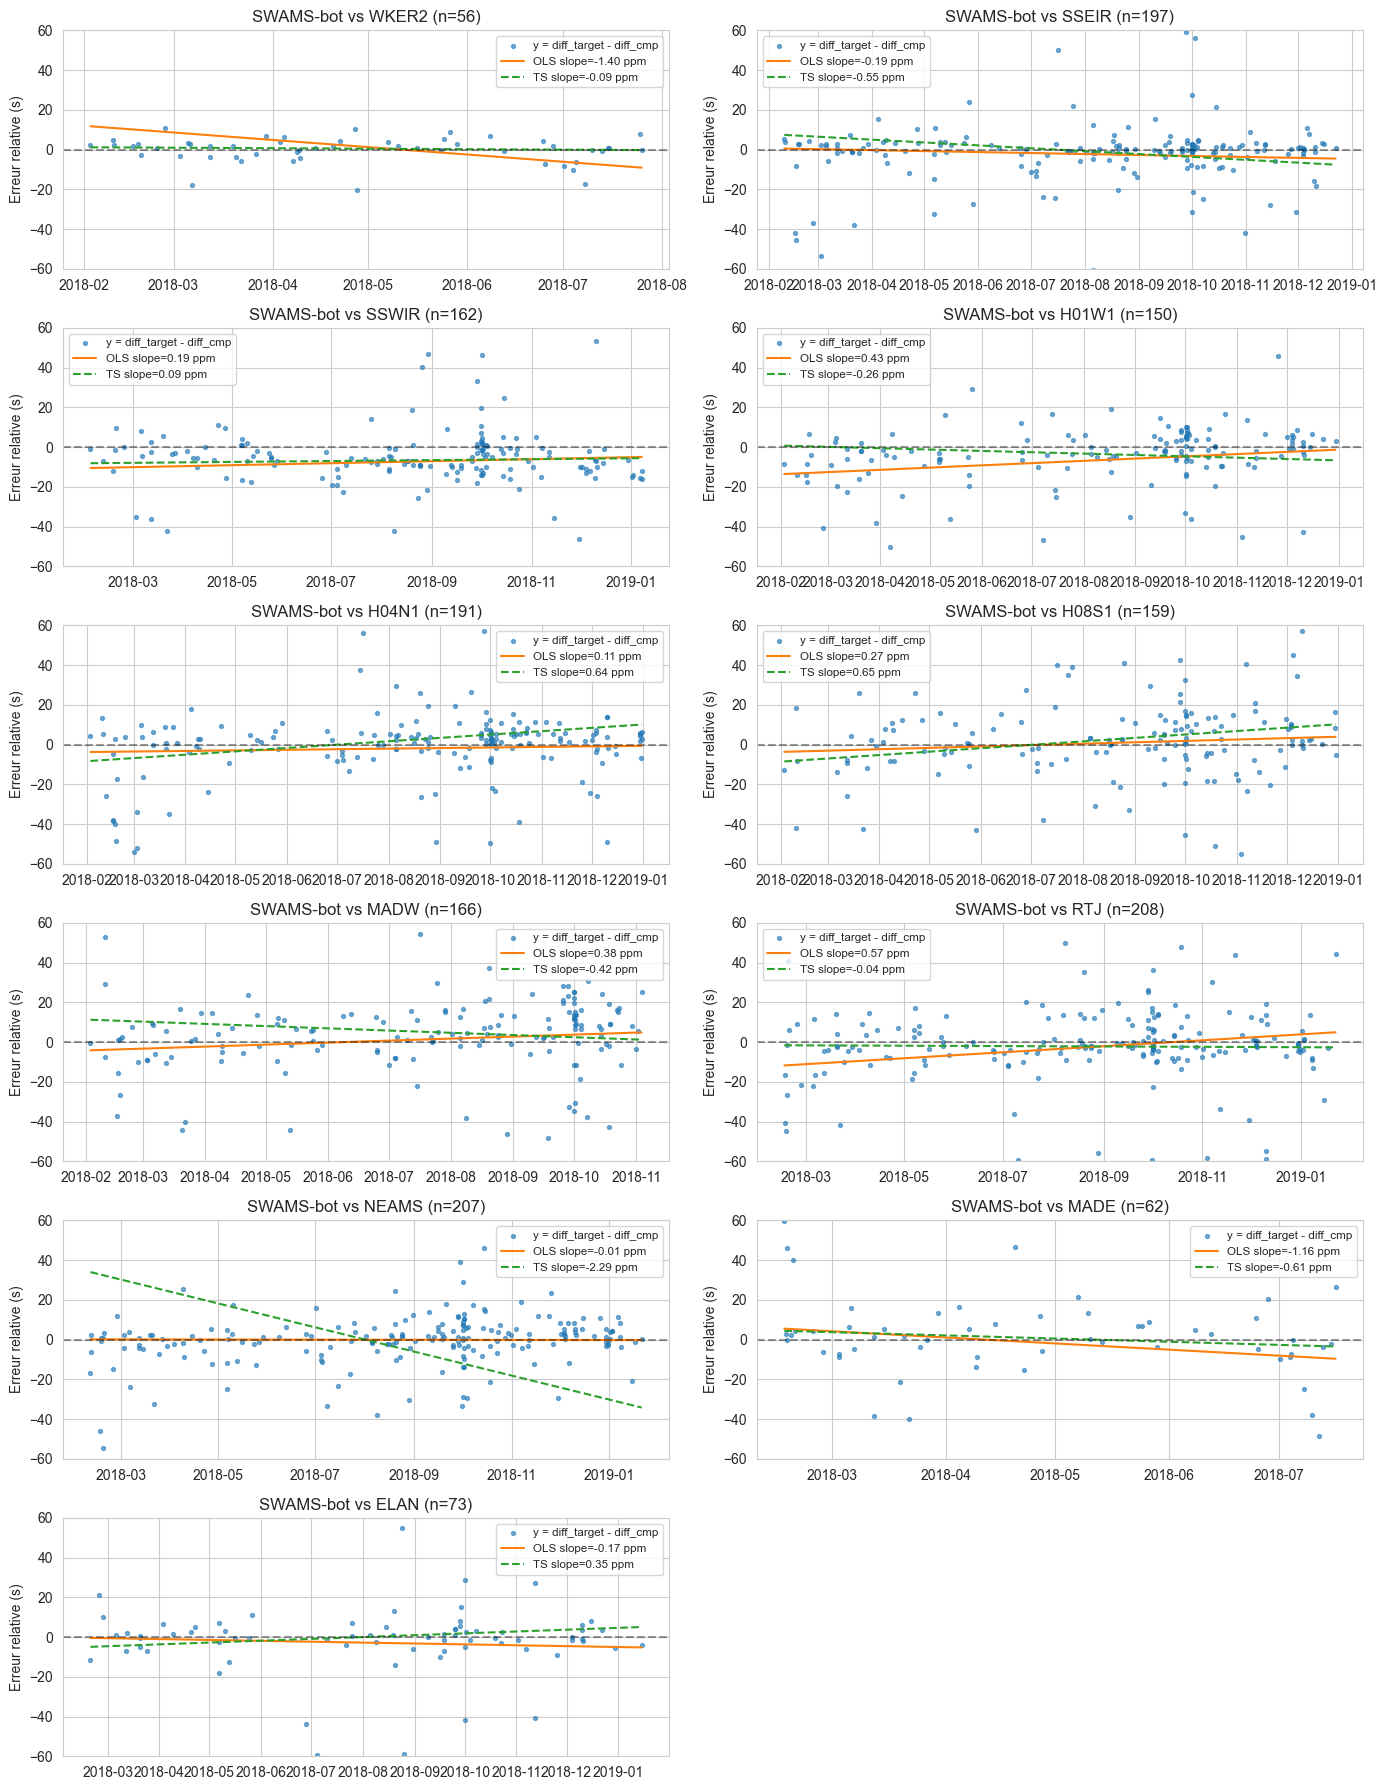

                   n  slope_ols_s_per_s  slope_ols_err_s_per_s  slope_ols_ppm  \
pair                                                                            
SWAMS-bot-WKER2   56      -1.395827e-06           8.811402e-07      -1.395827   
SWAMS-bot-MADE    62      -1.162157e-06           1.123432e-06      -1.162157   
SWAMS-bot-SSEIR  197      -1.853820e-07           2.536812e-07      -0.185382   
SWAMS-bot-ELAN    73      -1.681956e-07           2.908385e-07      -0.168196   
SWAMS-bot-NEAMS  207      -1.262354e-08           2.325392e-07      -0.012624   
SWAMS-bot-H04N1  191       1.098140e-07           3.195301e-07       0.109814   
SWAMS-bot-SSWIR  162       1.907090e-07           2.725080e-07       0.190709   
SWAMS-bot-H08S1  159       2.653211e-07           3.020742e-07       0.265321   
SWAMS-bot-MADW   166       3.814881e-07           3.358313e-07       0.381488   
SWAMS-bot-H01W1  150       4.290153e-07           2.748608e-07       0.429015   
SWAMS-bot-RTJ    208       5

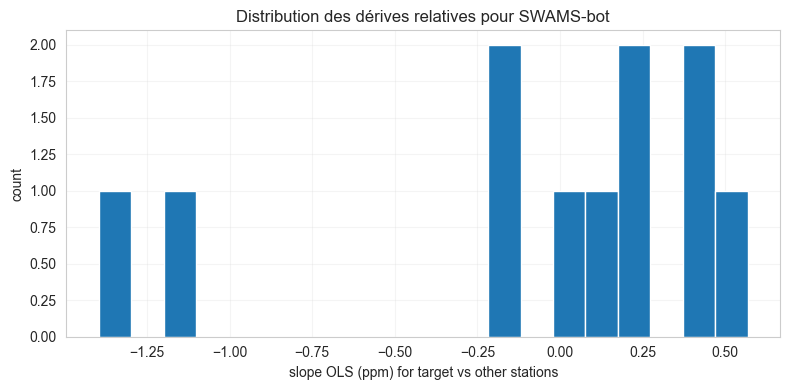

In [352]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.linear_model import TheilSenRegressor

# Entrées
stations = list(names.values())   # liste des 12 stations
target = 'SWAMS-bot'                   # changer pour la station que vous voulez vérifier
bins = 40

# Préparer le vecteur temps en secondes (float), centré pour stabilité numérique
date_series = sumatra_final['date'].dt.tz_convert('UTC')
t_sec = (date_series - date_series.mean()).dt.total_seconds().values  # centrée
t_abs = (date_series).values  # pour l'affichage en x (datetime64[ns, UTC])

results = []

plt.figure(figsize=(14, 18))
plot_idx = 1

for cmp in stations:
    if cmp == target:
        continue

    col_t = f'diff_{target}'
    col_c = f'diff_{cmp}'

    # Mask : événements où les deux stations ont une valeur
    mask = sumatra_final[col_t].notna() & sumatra_final[col_c].notna()
    n_pts = mask.sum()
    if n_pts < 5:
        print(f"Paired {target} vs {cmp}: trop peu de points ({n_pts}), skip.")
        continue

    y = (sumatra_final.loc[mask, col_t] - sumatra_final.loc[mask, col_c]).values  # en secondes
    t = t_sec[mask]  # centrée en secondes
    dates = sumatra_final.loc[mask, 'date']

    # --- OLS (linregress) ---
    ols = linregress(t, y)
    slope_ols = ols.slope            # s / s
    intercept_ols = ols.intercept
    r_value = ols.rvalue
    # calculer erreur standard de la pente
    residuals = y - (slope_ols * t + intercept_ols)
    sigma2 = np.sum(residuals**2) / max(n_pts - 2, 1)
    slope_err = np.sqrt(sigma2 / np.sum((t - np.mean(t))**2))

    # --- Theil-Sen (robuste) ---
    try:
        ts_model = TheilSenRegressor(random_state=0).fit(t.reshape(-1,1), y)
        slope_ts = ts_model.coef_[0]
        intercept_ts = ts_model.intercept_
    except Exception as e:
        slope_ts = np.nan
        intercept_ts = np.nan

    # convertir en ppm
    slope_ols_ppm = slope_ols * 1e6
    slope_ts_ppm = slope_ts * 1e6 if not np.isnan(slope_ts) else np.nan
    slope_err_ppm = slope_err * 1e6

    results.append({
        'pair': f'{target}-{cmp}',
        'n': int(n_pts),
        'slope_ols_s_per_s': slope_ols,
        'slope_ols_err_s_per_s': slope_err,
        'slope_ols_ppm': slope_ols_ppm,
        'slope_ts_s_per_s': slope_ts,
        'slope_ts_ppm': slope_ts_ppm,
        'r_value': r_value
    })

    # --- plotting (scatter + regressions) ---
    plt.subplot(6, 2, plot_idx)
    plt.title(f'{target} vs {cmp} (n={n_pts})')
    plt.scatter(dates, y, s=8, alpha=0.6, label='y = diff_target - diff_cmp')
    # OLS line
    x_plot = (dates - date_series.mean()).dt.total_seconds().values
    y_ols_line = slope_ols * x_plot + intercept_ols
    plt.plot(dates, y_ols_line, '-', label=f'OLS slope={slope_ols_ppm:.2f} ppm', color='C1')
    # Theil-Sen line
    if not np.isnan(slope_ts):
        y_ts_line = slope_ts * x_plot + intercept_ts
        plt.plot(dates, y_ts_line, '--', label=f'TS slope={slope_ts_ppm:.2f} ppm', color='C2')
    plt.axhline(0, linestyle='--', color='k', alpha=0.4)
    plt.ylabel('Erreur relative (s)')
    plt.ylim(-60,60)
    plt.legend(fontsize='small')
    plot_idx += 1

# tidy and show
plt.tight_layout()
plt.show()

# Résumé tabulaire
df_pairs = pd.DataFrame(results).set_index('pair').sort_values('slope_ols_ppm')
print(df_pairs)

# Plot histogram of slopes (ppm) to see dispersion across pairs
plt.figure(figsize=(8,4))
plt.hist(df_pairs['slope_ols_ppm'].dropna(), bins=20)
plt.xlabel('slope OLS (ppm) for target vs other stations')
plt.ylabel('count')
plt.title(f'Distribution des dérives relatives pour {target}')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [353]:
import numpy as np
import pandas as pd
from numpy.linalg import lstsq, inv, pinv

REF = 'SWAMS-bot'
CORE = [
    'SSEIR',  'RTJ',
    'NEAMS', 'MADW', 'SSWIR','MADE','WKER2','ELAN',
]  # SWAMS-bot retirée

N = len(CORE)
idx = {s: i for i, s in enumerate(CORE)}

# temps en secondes UTC
t_evt = sumatra_final['date'].dt.tz_convert('UTC').astype('int64') / 10**9
t_evt = t_evt.values

t0 = {
    s: int(pd.Timestamp(start_times[s]).timestamp())
    for s in CORE
}


In [354]:
N = len(CORE)
idx = {s: i for i, s in enumerate(CORE)}
MAX_REL_ERR = 20 # secondes


A_rows = []
b_vals = []

for k, t in enumerate(t_evt):
    row = sumatra_final.iloc[k]

    for i, si in enumerate(CORE):
        vi = row.get(f'diff_{si}', np.nan)
        if pd.isna(vi):
            continue

        vref = row.get(f'diff_{REF}', np.nan)
        if not pd.isna(vref):
            b = vi - vref
            if abs(b) <= MAX_REL_ERR:
                arow = np.zeros(N)
                arow[i] = (t - t0[si])
                A_rows.append(arow)
                b_vals.append(b)

        for j in range(i + 1, N):
            sj = CORE[j]
            vj = row.get(f'diff_{sj}', np.nan)
            if pd.isna(vj):
                continue

            b = vi - vj
            if abs(b) <= MAX_REL_ERR:
                arow = np.zeros(N)
                arow[i] = (t - t0[si])
                arow[j] = -(t - t0[sj])
                A_rows.append(arow)
                b_vals.append(b)


A = np.vstack(A_rows)
b = np.array(b_vals)


In [355]:
print("Nombre d'équations :", len(b_vals))
print("max |b| :", np.max(np.abs(b_vals)))
print("median |b| :", np.median(np.abs(b_vals)))


Nombre d'équations : 3938
max |b| : 19.953744115
median |b| : 5.1061131185


In [356]:
def huber_weights(r, sigma, c=0.345):
    z = np.abs(r / sigma)
    w = np.ones_like(z)
    mask = z > c
    w[mask] = c / z[mask]
    return w


In [357]:
def solve_ls(A, b, W=None):
    if W is None:
        return np.linalg.lstsq(A, b, rcond=None)[0]
    w = np.sqrt(W)
    return np.linalg.lstsq(A * w[:, None], b * w, rcond=None)[0]

x = solve_ls(A, b)
W = np.ones(len(b))

for _ in range(10000):
    r = A @ x - b
    sigma = 1.4826 * np.median(np.abs(r - np.median(r)))
    if sigma == 0:
        break
    W_new = huber_weights(r, sigma)
    x_new = solve_ls(A, b, W=W_new)
    if np.linalg.norm(x_new - x) < 1e-12:
        break
    x, W = x_new, W_new


In [358]:
df_core = pd.DataFrame({
    'station': CORE,
    'drift_ppm': x * 1e6
}).set_index('station')

df_core.loc[REF] = 0.0
print(df_core)


           drift_ppm
station             
SSEIR       0.013652
RTJ         0.004568
NEAMS       0.034030
MADW        0.045732
SSWIR      -0.140608
MADE        0.036234
WKER2       0.011379
ELAN        0.010604
SWAMS-bot   0.000000


In [359]:
names

{1: 'WKER2',
 2: 'SSEIR',
 3: 'SWAMS-bot',
 4: 'SSWIR',
 5: 'H01W1',
 6: 'H04N1',
 7: 'H08S1',
 8: 'MADW',
 9: 'RTJ',
 10: 'NEAMS',
 11: 'MADE',
 12: 'ELAN'}